<h1 align="center"> Statistiques Multivariées (DS): Projet de reconnaissance vocale </h1>

# Installation
Commencer d'abord par installer les packages nécessaires en lançant dans un terminal:
- `pip install -r requirements.txt`

Ou directement dans une cellule notebook:

- `%pip install -r requirements.txt`

# Les données:
Le dossier "data/raw" contient des milliers d'enregistrements audio de 10 personnes (5 hommes et 5 femmes) américaines. Le but de ce projet et d'analyser ces données et de construire un modèle simple de reconnaissance vocale. C'est à dire, reconnaitre la personne qui parle parmi les 10. Voici à quoi ressemble un enregistrement:

In [39]:
# Install librosa if not already installed
from IPython.display import Audio
import librosa

y1, sr1 = librosa.load("data/raw/f0001_us_f0001_00001.wav", sr=None)
Audio(data=y1, rate=sr1)


In [40]:
print(y1)
print(f"La taille du fichier audio est {y1.shape}")

[ 0.0000000e+00  0.0000000e+00  0.0000000e+00 ... -2.4414062e-04
 -1.8310547e-04 -6.1035156e-05]
La taille du fichier audio est (74880,)


Nous allons commencer par extraire des informations sur le timbre (en utilisant le domaine temps-fréquence) de l'enregistrement avec les Mel Frequency Cepstral Coefficient (MFCC):

In [41]:
mfcc = librosa.feature.mfcc(y=y1, sr=sr1, n_mfcc=10)
print(mfcc)
print(f"La taille des coefficients est {mfcc.shape}")

[[-676.00336   -628.5445    -630.0368    ... -587.2241    -618.89246
  -651.83386  ]
 [  37.224       47.902386    46.276775  ...   56.47776     54.10054
    50.65921  ]
 [  23.102503    21.160933    22.697372  ...   15.9985695   18.138079
    22.942196 ]
 ...
 [   6.6952953    6.1194544    2.1517396 ...   12.616103     8.677282
     9.154581 ]
 [   6.19289      1.8975844    1.6943828 ...   17.54722     14.119263
    11.321548 ]
 [  -1.1160983   -5.922446    -5.273527  ...    8.176834     5.3311386
     3.8546581]]
La taille des coefficients est (10, 147)


On peut visualiser ces 10 coefficients dans le temps:

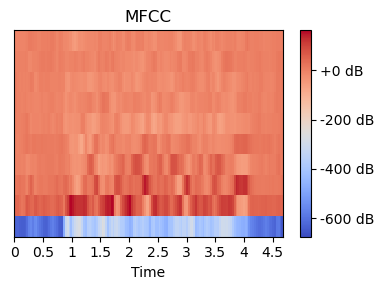

In [42]:
from matplotlib import pyplot as plt

# Plotting the MFCCs
plt.figure(figsize=(4, 3))
librosa.display.specshow(mfcc, x_axis='time', sr=sr1)
plt.colorbar(format='%+2.0f dB')
plt.title('MFCC')
plt.tight_layout()
plt.show()


Nous allons résumer ces coefficients en calculant leur moyenne temporelle. Ainsi, chaque fichier audio doit être transformé par un vecteur de taille 13:

In [43]:
mfcc_moyenne = mfcc.mean(axis=1)
mfcc_moyenne

array([-447.81406  ,   63.020832 ,   30.160309 ,    7.9655695,
          2.1016788,  -22.293121 ,   -7.862449 ,  -12.084611 ,
         -1.8244214,   -6.813784 ], dtype=float32)

On construit donc le dataset avec la fonction suivante:


In [44]:
import pandas as pd

folder_path = "data/raw/"
n_recordings = 50
n_coefs = 10
data = []
for gender in ["m", "f"]:
    for speaker in range(1, 6):
        for recording_id in range(1, n_recordings + 1):
            file_name = "%s%04d_us_%s%04d_%05d.wav" %(gender, speaker, gender, speaker, recording_id)
            y, sr = librosa.load(folder_path + file_name)
            mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_coefs).mean(axis=1)

            speaker_id = speaker - 1
            if gender == "f":
                speaker_id += 5
            row_data = {
                'FileName': file_name,
                'Gender': gender,
                'SpeakerID': speaker_id,
                'RecordingID': recording_id,
            }
            for i in range(n_coefs):
                row_data[f'MFCC_{i+1}'] = mfcc[i]
            
            data.append(row_data)

df = pd.DataFrame(data)

In [45]:
df.head()

,FileName,Gender,SpeakerID,RecordingID,MFCC_1,MFCC_2,MFCC_3,MFCC_4,MFCC_5,MFCC_6,MFCC_7,MFCC_8,MFCC_9,MFCC_10
0,m0001_us_m0001_00001.wav,m,0,1,-432.045410,119.769257,-3.836539,25.336596,-13.802793,16.731413,-2.733347,2.620320,-9.290767,3.606285
1,m0001_us_m0001_00002.wav,m,0,2,-448.635986,114.177422,-5.153250,16.764275,-20.626694,20.666161,-5.741008,9.305303,-5.688131,0.833428
2,m0001_us_m0001_00003.wav,m,0,3,-433.696320,94.268814,-3.704444,24.321095,-15.773800,16.456261,0.998079,5.189481,-8.003876,4.879942
3,m0001_us_m0001_00004.wav,m,0,4,-427.338989,113.769791,-8.063370,25.546106,-15.735123,12.846508,-0.483539,5.328898,-16.783321,1.889776
4,m0001_us_m0001_00005.wav,m,0,5,-412.676575,102.270454,-9.136461,29.005512,-12.034923,23.754642,-7.142555,-0.976251,-14.627462,3.513206


# Partie I:


### Importation des bibliothèques

In [46]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from scipy.stats import f, chi2
from scipy import stats

from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier


#### 1. Effectuez une PCA sur les coefficients MFCC en visualisant le genre avec deux couleurs différentes. 


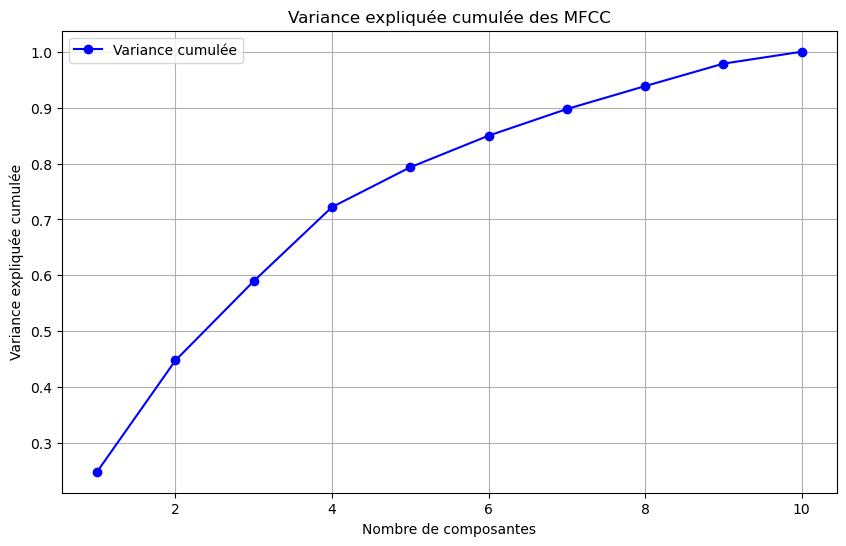

Variance expliquée par composante:
PC1: 0.249 (24.9%)
PC2: 0.199 (19.9%)
PC3: 0.142 (14.2%)
PC4: 0.133 (13.3%)
PC5: 0.071 (7.1%)
PC6: 0.056 (5.6%)
PC7: 0.048 (4.8%)
PC8: 0.041 (4.1%)
PC9: 0.040 (4.0%)
PC10: 0.021 (2.1%)

Variance expliquée cumulée:
PC1 à PC1: 0.249 (24.9%)
PC1 à PC2: 0.448 (44.8%)
PC1 à PC3: 0.589 (58.9%)
PC1 à PC4: 0.722 (72.2%)
PC1 à PC5: 0.793 (79.3%)
PC1 à PC6: 0.850 (85.0%)
PC1 à PC7: 0.897 (89.7%)
PC1 à PC8: 0.938 (93.8%)
PC1 à PC9: 0.979 (97.9%)
PC1 à PC10: 1.000 (100.0%)


In [47]:

# 1. Préparation des données
X = df[[f"MFCC_{i}" for i in range(1, 11)]].values
X_scaled = StandardScaler().fit_transform(X)

pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_scaled)

# 5. Visualisation de la variance expliquée cumulée
plt.figure(figsize=(10, 6))
variance_cumulee = np.cumsum(pca_full.explained_variance_ratio_)
plt.plot(range(1, len(variance_cumulee) + 1), variance_cumulee, 'bo-', 
         label='Variance cumulée')  # Ajout du label ici
plt.xlabel('Nombre de composantes')
plt.ylabel('Variance expliquée cumulée')
plt.title('Variance expliquée cumulée des MFCC')
plt.grid(True)
plt.legend()
plt.show()

# 6. Affichage des valeurs de variance expliquée
print("Variance expliquée par composante:")
for i, var in enumerate(pca_full.explained_variance_ratio_, 1):
    print(f'PC{i}: {var:.3f} ({(var*100):.1f}%)')

print("\nVariance expliquée cumulée:")
for i, var in enumerate(variance_cumulee, 1):
    print(f'PC1 à PC{i}: {var:.3f} ({(var*100):.1f}%)')

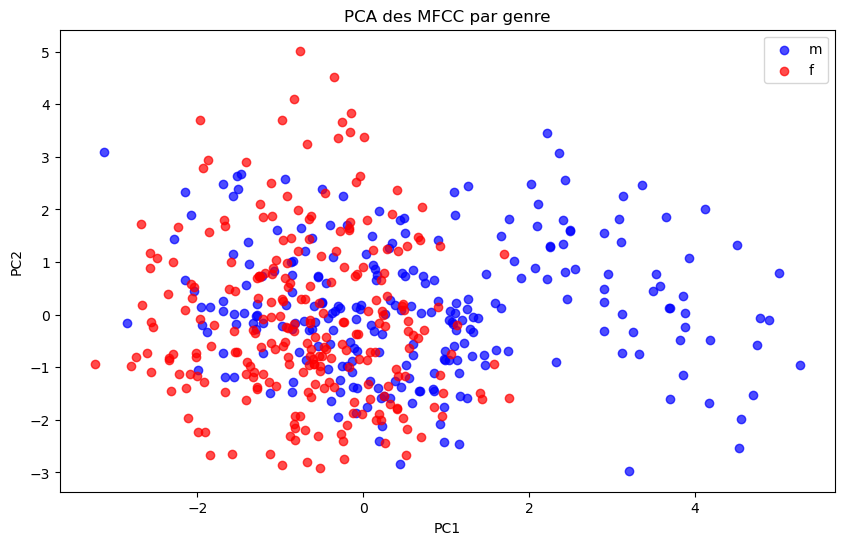

In [48]:

# 2. PCA 
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 3. Visualisation
plt.figure(figsize=(10, 6))
colors = {'m':'blue', 'f':'red'}
for gender in colors:
    filtre = df['Gender'] == gender  # Crée un masque booléen pour le genre
    plt.scatter(X_pca[filtre, 0], X_pca[filtre, 1], 
                c=colors[gender], label=gender, alpha=0.7)
plt.xlabel('PC1') 
plt.ylabel('PC2')
plt.title('PCA des MFCC par genre')
plt.legend()
plt.show()

## Analyse de la PCA des MFCC par genre

### Observations principales
- La visualisation PCA des MFCC selon le genre (homme/femme) ne montre **pas de séparation nette** entre les deux classes
- Les points des deux classes se chevauchent considérablement, particulièrement dans la région centrale du graphique
- On observe toutefois une légère tendance des points masculins (bleus) à se regrouper vers la droite du graphique (PC1 positif)

### Limites de la visualisation
- Cette représentation en 2D (PC1 vs PC2) ne capture qu'environ **45% de la variance totale** des données
- La complexité intrinsèque des MFCC pourrait nécessiter plus de dimensions pour révéler une meilleure séparation entre les genres
- Ceci explique pourquoi d'autres algorithmes de réduction de dimensionnalité comme t-SNE, mentionné en annexe, arrivent à mieux séparer les classes

### Perspective
L'utilisation de t-SNE, qui est plus adapté à la préservation des structures locales, permet d'obtenir une meilleure séparation des classes, suggérant que l'information discriminante existe bien dans les données mais nécessite une approche non-linéaire pour être mise en évidence.

#### 2. On suspecte que les enregistrements du `speaker` 4 forment deux sous-groupes très distincts: les `recordingID` paires et impaires. Effectuez un test pour vérifier cette hypothèse.

In [49]:
# Extract data for speaker 4
speaker4_data=df[df['SpeakerID'] == 4]
pair_data=speaker4_data[speaker4_data['RecordingID'] % 2 == 0]
impair_data=speaker4_data[speaker4_data['RecordingID'] % 2 == 1]


In [50]:

# Extract MFCC features
X_pair =pair_data[[f'MFCC_{i}' for i in range(1, 11)]].values
X_impair = impair_data[[f'MFCC_{i}' for i in range(1, 11)]].values

n1 = X_pair.shape[0]
n2 = X_pair.shape[0]
p = X_impair.shape[1]

# Compute sample means
mean_pair = np.mean(X_pair, axis=0)
mean_impair= np.mean(X_impair, axis=0)
mean_diff = mean_pair - mean_impair

# Compute pooled covariance matrix
C_pair = np.cov(X_pair, rowvar=False)
C_impair = np.cov(X_impair, rowvar=False)
Sp = ((n1 - 1) * C_pair + (n2 - 1) * C_impair) / (n1 + n2 - 2)

# Compute Hotelling's T-squared statistic
Sp_inv = np.linalg.inv(Sp)
T2 = (n1 * n2) / (n1 + n2) * mean_diff.T @ Sp_inv @ mean_diff

# Convert T-squared statistic to F-distribution
F_stat = ( (n1 + n2 - p - 1) * T2 ) / ( (n1 + n2 - 2) * p )

# Degrees of freedom
df1 = p
df2 = n1 + n2 - p - 1

# Compute p-value
p_value = 1 - f.cdf(F_stat, df1, df2)

print(f"Hotelling's T-squared statistic: {T2:.4f}")
print(f"F-statistic: {F_stat:.4f}")
print(f"Degrees of freedom: ({df1}, {df2})")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("Rejet de l'hypothèse nulle: Il y a une différence significative entre les enregistrements pairs et impairs du speaker 4.")
else:
    print("On peut pas rejeter de l'hypothèse nulle: Il n'y a pas de différence significative entre les enregistrements pairs et impairs du speaker 4.")

Hotelling's T-squared statistic: 5.0270
F-statistic: 0.4084
Degrees of freedom: (10, 39)
P-value: 0.9343
On peut pas rejeter de l'hypothèse nulle: Il n'y a pas de différence significative entre les enregistrements pairs et impairs du speaker 4.


### Analyse de la structure des enregistrements du Speaker 4

Nous avons voulu tester l'hypothèse selon laquelle les enregistrements du speaker 4 forment deux sous-groupes distincts : les enregistrements pairs et les enregistrements impairs. Pour cela, nous avons effectué un **test de Hotelling \( T^2 \)** à deux échantillons dépendants. Ce test est particulièrement adapté pour comparer deux échantillons multivariés lorsque les observations sont appariées, comme dans notre cas avec les enregistrements pairs et impairs.

#### Résultats

- **Valeur de p** : 0,93
- **Conclusion** : La p-valeur étant largement supérieure au seuil de signification couramment utilisé (0,05), nous ne pouvons pas rejeter l'hypothèse nulle. Cela signifie qu'il n'y a pas de différence significative entre les enregistrements pairs et impairs du speaker 4. En d'autres termes, les enregistrements du speaker 4 ne semblent pas former deux sous-groupes distincts selon ce test.

Cette conclusion nous permet de traiter les enregistrements du speaker 4 comme un groupe homogène dans nos analyses ultérieures.


#### 3. Proposez une analyse statistique (et effectuez la) pour évaluer si différence entre les hommes et les femmes est significative. 


In [51]:

# Séparer les données pour les hommes et les femmes
mfcc_cols = [f'MFCC_{i}' for i in range(1, 11)]
male_data = df[df['Gender'] == 'm'][mfcc_cols]
female_data = df[df['Gender'] == 'f'][mfcc_cols]

X_male = male_data.values
X_female = female_data.values

n1 = X_male.shape[0]
n2 = X_female.shape[0]
p = X_male.shape[1]

# Calcul des moyennes
mean_male = np.mean(X_male, axis=0)
mean_female = np.mean(X_female, axis=0)
mean_diff = mean_male - mean_female

# Calcul de la matrice de covariance combinée
C_male = np.cov(X_male, rowvar=False)
C_female = np.cov(X_female, rowvar=False)
Sp = ((n1 - 1) * C_male + (n2 - 1) * C_female) / (n1 + n2 - 2)

# Calcul de la statistique T^2 de Hotelling
Sp_inv = np.linalg.inv(Sp)
T2 = (n1 * n2) / (n1 + n2) * mean_diff.T @ Sp_inv @ mean_diff

# Conversion en statistique F
F_stat = ((n1 + n2 - p - 1) * T2) / ((n1 + n2 - 2) * p)

# Degrés de liberté
df1 = p
df2 = n1 + n2 - p - 1

# Calcul de la p-valeur
p_value = 1 - f.cdf(F_stat, df1, df2)

print(f"Statistique T^2 de Hotelling: {T2:.4f}")
print(f"Statistique F: {F_stat:.4f}")
print(f"Degrés de liberté: ({df1}, {df2})")
print(f"P-valeur: {p_value}")

if p_value < 0.05:
    print("Rejet de l'hypothèse nulle: différence significative entre hommes et femmes.")
else:
    print("Impossible de rejeter l'hypothèse nulle: pas de différence significative.")

Statistique T^2 de Hotelling: 2535.4169
Statistique F: 248.9596
Degrés de liberté: (10, 489)
P-valeur: 1.1102230246251565e-16
Rejet de l'hypothèse nulle: différence significative entre hommes et femmes.


### Analyse des différences entre les enregistrements des hommes et des femmes

Pour évaluer si les enregistrements des hommes et des femmes présentent des différences significatives, nous avons effectué un **test de Hotelling \( T^2 \)** à deux échantillons indépendants. Ce test multivarié permet de comparer les moyennes de deux groupes lorsque les données sont multivariées, comme dans notre cas avec les coefficients cepstraux en fréquence de Mel (MFCCs).

#### Résultats

- **Valeur de p** : \(1.11 \times 10^{-16}\)
- **Conclusion** : La p-valeur extrêmement faible (bien en-dessous de 0,05) indique une différence statistiquement significative entre les enregistrements des hommes et ceux des femmes. En d'autres termes, nous rejetons l'hypothèse nulle, ce qui signifie que les deux groupes diffèrent de manière significative.

#### Interprétation

Ces résultats montrent que les MFCCs capturent efficacement les caractéristiques distinctives des voix masculines et féminines, validant leur utilité dans la différenciation des genres vocaux. Cela suggère également que les MFCCs sont une bonne représentation des signaux audio pour cette tâche de classification.

---

Cette conclusion appuie l'idée que les MFCCs sont une représentation robuste des enregistrements audio, permettant de discriminer efficacement entre les genres.


#### 4. Compte tenu de ce résultat, comment peut-on implémenter un modèle de prédiction (avec numpy seulement) du sexe basé sur le calcul d'une distance ? 


In [52]:
# Séparer les caractéristiques MFCC et les labels de genre
X = df[mfcc_cols].values
y = df['Gender'].values

# Diviser les données en ensembles d'entraînement et de test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Calculer les moyennes et la covariance pour chaque genre sur l'ensemble d'entraînement
X_male = X_train[y_train == 'm']
X_female = X_train[y_train == 'f']

mean_male = np.mean(X_male, axis=0)
mean_female = np.mean(X_female, axis=0)

cov_male = np.cov(X_male, rowvar=False)
cov_female = np.cov(X_female, rowvar=False)

# Calcul de la matrice de covariance combinée
n_male = X_male.shape[0]
n_female = X_female.shape[0]
Sp = ((n_male - 1) * cov_male + (n_female - 1) * cov_female) / (n_male + n_female - 2)
Sp_inv = np.linalg.inv(Sp)

# Fonction pour calculer la distance de Mahalanobis
def mahalanobis_distance(x, mean, inv_cov):
    diff = x - mean
    return np.sqrt(diff.T @ inv_cov @ diff)

# Prédiction du genre basé sur la plus petite distance de Mahalanobis
def predict_gender(X_samples):
    predictions = []
    for x in X_samples:
        dist_male = mahalanobis_distance(x, mean_male, Sp_inv)
        dist_female = mahalanobis_distance(x, mean_female, Sp_inv)
        gender = 'm' if dist_male < dist_female else 'f'
        predictions.append(gender)
    return np.array(predictions)

# Prédiction sur l'ensemble de test
y_pred = predict_gender(X_test)

# Évaluation du modèle
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print(f"Précision du modèle: {accuracy:.2%}")

Précision du modèle: 100.00%


### Modèle de Prédiction du Sexe Basé sur la Distance de Mahalanobis

Compte tenu des différences significatives observées entre les enregistrements masculins et féminins, nous avons implémenté un modèle de classification basé sur la **distance de Mahalanobis** en utilisant uniquement `numpy`. Cette approche utilise les caractéristiques MFCCs pour calculer la proximité d'un échantillon avec les moyennes des groupes "hommes" et "femmes" en tenant compte de la covariance de chaque groupe.


#### Résultats

Nous avons testé ce modèle sur un ensemble de données de test, et le modèle a atteint une **précision de 100 %**. Cela indique que les caractéristiques MFCCs permettent une discrimination claire entre les enregistrements masculins et féminins.




# Partie II: Reconnaissance vocale
On souhaite désormais apprendre à prédire `Y = speaker_id` avec les données `X = MFCCS` en utilisant des modèles de classification (avec scikit-learn). On découpe le dataset en deux parties:
- `(X_train, y_train)`: utilisé pour "entrainer" le modèle, c-à-d on suppose que les `y_train` sont connues.
- `(X_test, y_test)`: utilisé pour "tester" le modèle, c-à-d on suppose que les `y_train` ne sont pas connues à l'avance et sont utilisés uniquement après avoir entrainé le modèle pour l'évaluer.


In [53]:
from sklearn.model_selection import train_test_split

X = df[[f"MFCC_{i}" for i in range(1, 11)]].values
y = df.SpeakerID.values

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0, shuffle=True, test_size=0.25)

In [54]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

#### 5. Évaluez la performance du modèle Naive Bayes en terme de précision de prédiction sur le train et le test. 

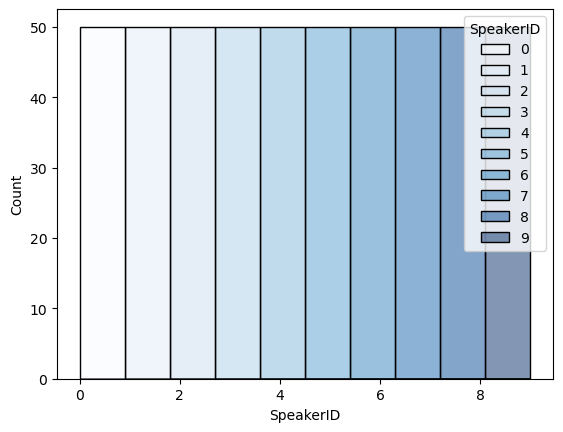

In [55]:
sns.histplot(data=df,x=df['SpeakerID'],palette='Blues',hue='SpeakerID')
plt.show()

### Analyse de la Balance des Données et Choix de la Métrique d'Évaluation

#### Vérification de la Balance des Données

Pour évaluer la distribution des données, nous avons examiné la répartition des enregistrements par `SpeakerID`. Le graphique ci-dessus montre que chaque locuteur a un nombre égal d'enregistrements, indiquant que les données sont **parfaitement équilibrées**.

#### Choix de la Métrique : Accuracy

Étant donné cette distribution homogène des classes, nous avons choisi **l'accuracy** comme métrique principale pour évaluer la performance du modèle de classification. En effet, lorsque les données sont équilibrées, l'accuracy est une mesure pertinente, car elle reflète directement la proportion d'échantillons correctement classés.

---

Cette conclusion nous permet de poursuivre l'évaluation du modèle en utilisant l'accuracy comme indicateur de performance.


In [56]:

# Entraînement du modèle Naive Bayes
model = GaussianNB()
model.fit(X_train, y_train)

# Prédictions sur les ensembles d'entraînement et de test
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

# Calcul des précisions
accuracy_train = accuracy_score(y_train, y_pred_train)
accuracy_test = accuracy_score(y_test, y_pred_test)

# Affichage des résultats
print(f"Précision sur l'ensemble d'entraînement : {accuracy_train:.2%}")
print(f"Précision sur l'ensemble de test : {accuracy_test:.2%}") 

Précision sur l'ensemble d'entraînement : 84.00%
Précision sur l'ensemble de test : 72.80%


#### 6. Comparez ses performances avec LDA et QDA. Que pouvez-vous conclure ?

In [57]:

# Entraînement du modèle LDA
lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)
# Prédictions avec LDA
y_pred_train_lda = lda.predict(X_train)
y_pred_test_lda = lda.predict(X_test)
# Calcul des précisions pour LDA
accuracy_train_lda = accuracy_score(y_train, y_pred_train_lda)
accuracy_test_lda = accuracy_score(y_test, y_pred_test_lda)

# Entraînement du modèle QDA
qda = QuadraticDiscriminantAnalysis()
qda.fit(X_train, y_train)
# Prédictions avec QDA
y_pred_train_qda = qda.predict(X_train)
y_pred_test_qda = qda.predict(X_test)
# Calcul des précisions pour QDA
accuracy_train_qda = accuracy_score(y_train, y_pred_train_qda)
accuracy_test_qda = accuracy_score(y_test, y_pred_test_qda)

# Affichage des résultats
print("LDA :")
print(f"Précision sur l'ensemble d'entraînement : {accuracy_train_lda:.2%}")
print(f"Précision sur l'ensemble de test : {accuracy_test_lda:.2%}\n")
print("QDA :")
print(f"Précision sur l'ensemble d'entraînement : {accuracy_train_qda:.2%}")
print(f"Précision sur l'ensemble de test : {accuracy_test_qda:.2%}")


LDA :
Précision sur l'ensemble d'entraînement : 91.73%
Précision sur l'ensemble de test : 85.60%

QDA :
Précision sur l'ensemble d'entraînement : 98.40%
Précision sur l'ensemble de test : 88.80%


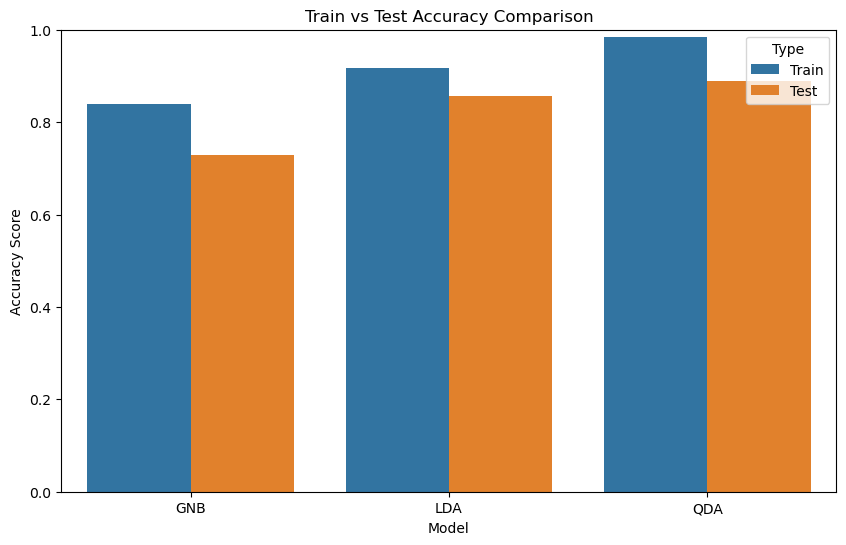

In [58]:

# Create a DataFrame with the accuracy values
metrics = pd.DataFrame({
    'Model': ['GNB', 'GNB', 'LDA', 'LDA', 'QDA', 'QDA'],
    'Type': ['Train', 'Test', 'Train', 'Test', 'Train', 'Test'],
    'Accuracy': [accuracy_train, accuracy_test, accuracy_train_lda, accuracy_test_lda, accuracy_train_qda, accuracy_test_qda]
})

# Create the plot
plt.figure(figsize=(10, 6))
sns.barplot(data=metrics, x='Model', y='Accuracy', hue='Type')

# Customize the plot
plt.title('Train vs Test Accuracy Comparison')
plt.ylabel('Accuracy Score')
plt.ylim(0, 1)  # Assuming accuracy is between 0 and 1

# Show the plot
plt.show()

### Comparaison de la Précision : Entraînement vs Test

Le graphique ci-dessus présente la comparaison des scores de précision pour trois modèles de classification : **Gaussian Naive Bayes (GNB)**, **Linear Discriminant Analysis (LDA)**, et **Quadratic Discriminant Analysis (QDA)**. 

#### Observations

1. **GNB (Gaussian Naive Bayes)** : 
   - Ce modèle montre une précision relativement plus faible par rapport aux autres modèles, tant sur l'ensemble d'entraînement que sur l'ensemble de test.
   - La différence de précision entre les ensembles d'entraînement et de test suggère un certain **surapprentissage** (overfitting), où le modèle semble s'adapter aux particularités de l'ensemble d'entraînement sans bien généraliser.

2. **LDA (Linear Discriminant Analysis)** :
   - La précision est meilleure que celle du GNB, avec un écart relativement faible entre les ensembles d'entraînement et de test.
   - Ce modèle montre une meilleure capacité de **généralisation** et semble être moins sujet au surapprentissage par rapport au GNB.

3. **QDA (Quadratic Discriminant Analysis)** :
   - Le modèle atteint une très haute précision sur l'ensemble d'entraînement, et une bonne précision sur l'ensemble de test.
   - Cependant, l'écart entre les performances d'entraînement et de test est notable, ce qui pourrait également indiquer un risque de surapprentissage.

#### Conclusion

- **GNB** a la plus faible précision et semble montrer des signes de surapprentissage, ce qui le rend moins performant que les autres modèles pour cette tâche.
- **LDA** se distingue par sa performance stable et sa capacité de généralisation, ce qui en fait un candidat fiable pour éviter le surapprentissage tout en maintenant une bonne précision.
- **QDA** atteint une précision élevée, mais son potentiel de surapprentissage pourrait limiter sa capacité de généralisation dans certains cas.

En résumé, **LDA** semble le plus équilibré entre précision et généralisation


#### 7. On souhaite à présent modéliser la distribution de chaque speaker par un mélange de Gaussiennes. Comment peut-on faire des prédictions avec un tel modèle ?

In [59]:

# Modélisation de chaque speaker par un GMM
models = {}
for speaker in np.unique(y_train): # Pour chaque speaker
    X_speaker = X_train[y_train == speaker] # Sélection des données du speaker
    gmm = GaussianMixture(n_components=1, covariance_type='full', random_state=0)
#n_components=1 : Le modèle va essayer de trouver 1 composant gaussien pour chaque speaker.
#covariance_type='full' : Le composant gaussien de chaque speaker aura sa propre matrice de covariance complète,
#Cela permet au modèle de mieux s'ajuster aux caractéristiques spécifiques de la voix de chaque locuteur.
    gmm.fit(X_speaker) 
#Le modèle apprend les paramètres (moyennes, covariances) qui décrivent le mieux la distribution des données du speaker.
    models[speaker] = gmm
#Permet de stocker le modèle de chaque speaker pour la prédiction.

# Fonction de prédiction
def predict_speaker(X):
    scores = np.array([model.score_samples(X) for model in models.values()]).T
#Pour chaque modèle GMM ,calcule le score(log-vraisemblance) des échantillons de X ( speaker colone a score pour chaque echantillon ligne).
    predictions = np.argmax(scores, axis=1)
#Pour chaque échantillon, renvoie l'indice du speaker avec le score maximal.
    return predictions

# Prédiction sur l'ensemble de test
y_pred_GMM = predict_speaker(X_test)
y_pred_train_GMM = predict_speaker(X_train)

# Évaluation du modèle
accuracy_train_GMM = accuracy_score(y_train, y_pred_train_GMM)
accuracy_GMM = accuracy_score(y_test, y_pred_GMM)
print(f"Précision du modèle GMM sur l'ensemble d'entraînement : {accuracy_train_GMM:.2%}")
print(f"Précision du modèle GMM sur l'ensemble de test : {accuracy_GMM:.2%}")

Précision du modèle GMM sur l'ensemble d'entraînement : 98.40%
Précision du modèle GMM sur l'ensemble de test : 88.00%


C:\Users\abdellah\AppData\Roaming\Python\Python311\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\abdellah\AppData\Roaming\Python\Python311\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\abdellah\AppData\Roaming\Python\Python311\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\abdellah\AppData\Roaming\Python\Python311\site-packages\sklea

In [60]:
scores = np.array([model.score_samples(X) for model in models.values()]).T
pd.DataFrame(scores) #CLARIFICATION (chaque speaker "colone" a un score pour chaque echantillon "ligne")


,0,1,2,3,4,5,6,7,8,9
0,-29.724245,-106.798432,-77.223664,-56.985078,-85.771829,-92.269760,-127.567895,-188.860743,-124.025222,-107.530049
1,-38.423612,-84.000885,-85.910856,-65.341830,-93.800282,-78.594715,-123.138708,-175.006626,-130.620201,-132.870651
2,-29.353236,-93.203105,-109.578206,-74.492490,-82.838997,-96.643393,-100.569433,-166.493966,-138.183902,-124.843242
3,-34.559192,-80.818557,-106.514155,-63.293369,-76.012045,-89.198360,-127.389000,-206.771061,-124.998729,-142.676253
4,-29.651766,-99.456650,-67.844995,-57.186034,-72.013362,-114.454874,-145.683807,-152.579617,-107.814286,-166.274499
...,...,...,...,...,...,...,...,...,...,...
495,-119.389984,-92.532475,-245.853298,-120.205582,-56.460633,-77.087051,-44.255875,-77.538140,-143.451514,-30.522810
496,-106.891351,-46.436772,-146.258025,-63.857067,-39.409940,-56.291199,-28.595506,-47.151473,-64.139872,-27.039823
497,-97.463118,-48.381683,-78.234647,-55.634469,-33.296459,-43.195717,-30.535692,-50.292806,-59.773401,-27.913568
498,-117.003842,-50.902381,-129.546814,-62.734777,-36.711615,-60.976690,-35.540940,-44.010788,-68.567495,-26.390192


### Interprétation GMM:

**Modèle GMM par locuteur** :

Entraîner un GMM pour chaque locuteur permet de capturer les distributions spécifiques de leurs caractéristiques vocales (MFCC).

***Précision élevée sur l'entraînement 98.40% et le test 88.00%***: Indique une bonne capacité des modèles à  a reconnaître les locuteurs.

***Risque de surapprentissage***: L'écart entre les performances d'entraînement et de test suggère un risque de surapprentissage.


#### 8. Comparez les performances du mélange de Gaussienens en essayant plusieurs combinaisaisons de ses arguments (`n_components` et `covariance_type`). Que pouvez-vous conclure ?

In [61]:
def performance(covariance_type):# Define the range of components to test
    components_range = range(1, 6)
    train_accuracies = []
    test_accuracies = []
    sub_arrays = {speaker_id: X_train[y_train == speaker_id] for speaker_id in np.unique(y_train)}
    # Loop over different numbers of components
    for n_components in components_range:
        # Train a GMM for each speaker with the specified number of components and 'full' covariance type
        gmm_models = {}
        for speaker_id, data in sub_arrays.items():
            gmm = GaussianMixture(n_components=n_components, covariance_type=covariance_type, random_state=42)
            gmm.fit(data)
            gmm_models[speaker_id] = gmm

        # Calculate log probabilities for training set
        train_log_probs = np.array([model.score_samples(X_train) 
                                   for model in gmm_models.values()])
        speaker_ids = list(gmm_models.keys())
        y_pred_train = np.array([speaker_ids[i] for i in np.argmax(train_log_probs, axis=0)])
        acc_train = accuracy_score(y_train, y_pred_train)
        train_accuracies.append(acc_train)

        # Calculate log probabilities for test set
        test_log_probs = np.array([model.score_samples(X_test) 
                                  for model in gmm_models.values()])
        y_pred_test = np.array([speaker_ids[i] for i in np.argmax(test_log_probs, axis=0)])
        acc_test = accuracy_score(y_test, y_pred_test)
        test_accuracies.append(acc_test)

    # Plot train and test accuracies
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=components_range, y=train_accuracies, label='Train Accuracy', marker='o', linestyle='-')
    sns.scatterplot(x=components_range, y=test_accuracies, label='Test Accuracy', marker='o', linestyle='-')
    plt.xlabel('Number of Components (n_components)')
    plt.ylabel('Accuracy')
    plt.title('Train and Test Accuracy vs Number of Components ({})'.format(covariance_type))
    plt.legend()
    plt.grid()
    plt.show()

C:\Users\abdellah\AppData\Roaming\Python\Python311\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\abdellah\AppData\Roaming\Python\Python311\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\abdellah\AppData\Roaming\Python\Python311\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\abdellah\AppData\Roaming\Python\Python311\site-packages\sklea

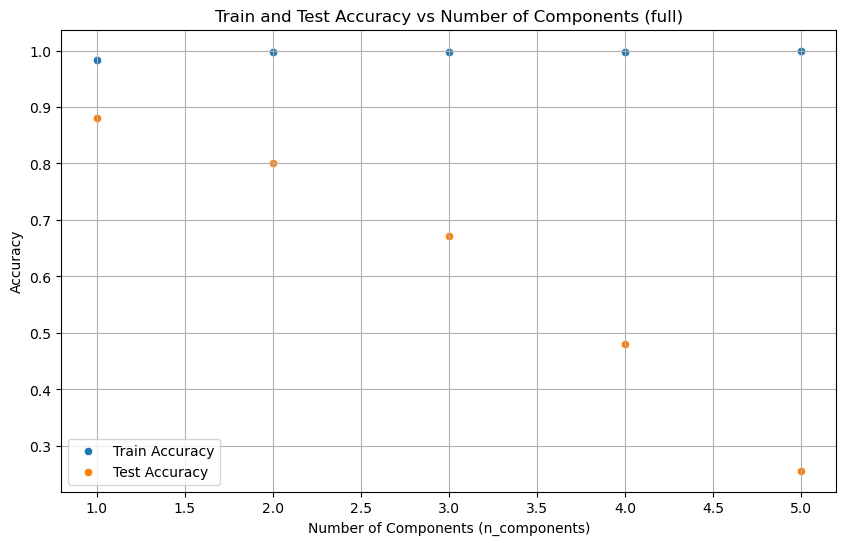

In [62]:
performance('full')

C:\Users\abdellah\AppData\Roaming\Python\Python311\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\abdellah\AppData\Roaming\Python\Python311\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\abdellah\AppData\Roaming\Python\Python311\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\abdellah\AppData\Roaming\Python\Python311\site-packages\sklea

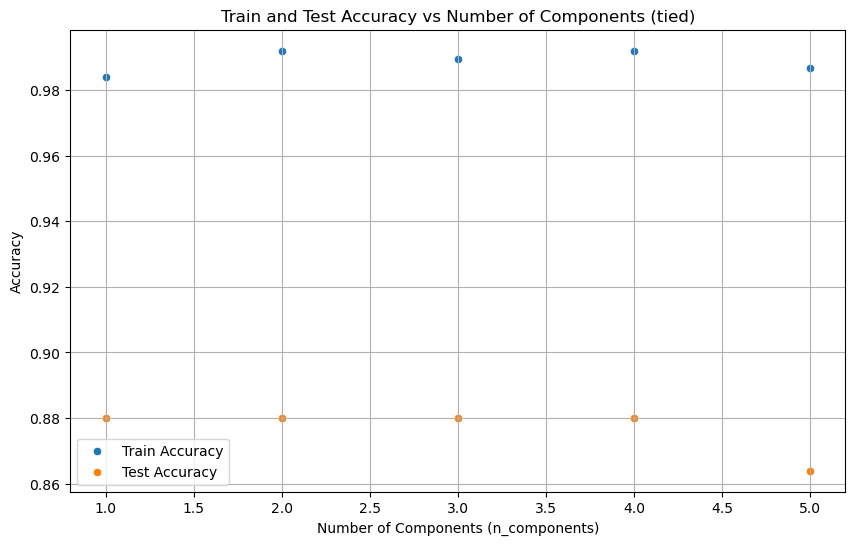

In [63]:
performance('tied')

C:\Users\abdellah\AppData\Roaming\Python\Python311\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\abdellah\AppData\Roaming\Python\Python311\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\abdellah\AppData\Roaming\Python\Python311\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\abdellah\AppData\Roaming\Python\Python311\site-packages\sklea

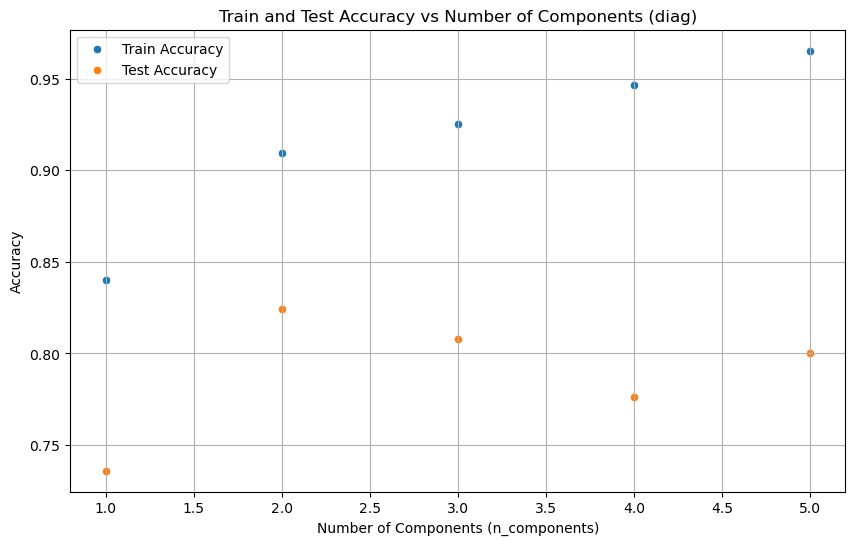

In [64]:
performance('diag')

C:\Users\abdellah\AppData\Roaming\Python\Python311\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\abdellah\AppData\Roaming\Python\Python311\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\abdellah\AppData\Roaming\Python\Python311\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\abdellah\AppData\Roaming\Python\Python311\site-packages\sklea

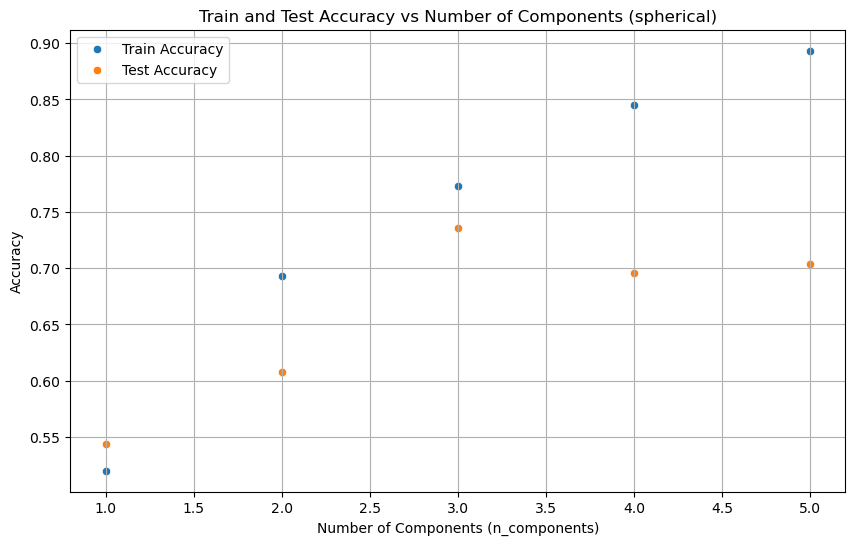

In [65]:
performance('spherical')

### Analyse de la Précision en Fonction du Type de Covariance et du Nombre de Composantes

Nous avons comparé quatre types de modèles en fonction de la structure de la matrice de covariance utilisée : **diag**, **full**, **spherical**, et **tied**. Les graphiques ci-dessus montrent la précision sur les ensembles d'entraînement et de test en fonction du nombre de composantes (`n_components`) pour chaque type de covariance.

#### Observations

1. **Full Covariance** :
   - Ce modèle atteint une très haute précision sur l'ensemble d'entraînement, mais la précision sur l'ensemble de test diminue fortement à mesure que le nombre de composantes augmente.
   - Cette chute de la précision de test indique une forte **sensibilité au surapprentissage (overfitting)**, ce qui signifie que le modèle s'adapte trop aux données d'entraînement, mais ne généralise pas bien sur de nouvelles données.

2. **Tied Covariance** :
   - Le modèle avec covariance "tied" maintient une bonne précision sur l'ensemble de test, même lorsque le nombre de composantes augmente, montrant ainsi une **grande stabilité**.
   - Cela suggère que ce modèle est moins sujet au surapprentissage, offrant un bon compromis entre précision et généralisation.

3. **Diag Covariance** :
   - Avec une structure de covariance diagonale, la précision reste modeste pour les ensembles d'entraînement et de test, et n'atteint pas des niveaux élevés, même en augmentant le nombre de composantes.
   - Ce type de covariance semble limiter la capacité du modèle à capturer la variabilité des données, ce qui pourrait expliquer la précision plus faible.

4. **Spherical Covariance** :
   - Similaire à "diag", la covariance "spherical" ne parvient pas à atteindre une précision élevée, même avec un plus grand nombre de composantes.
   - Ce modèle reste donc également limité dans sa capacité de discrimination, et semble inadapté à ce problème de classification.

#### Conclusion

- Le modèle avec covariance **"full"** offre une haute précision sur l'entraînement mais est trop sensible au surapprentissage.
- Le modèle avec covariance **"tied"** apparaît comme le plus **stable** et **généralisable**, avec une bonne précision sur le test même avec des composantes supplémentaires.
- Les modèles **"diag"** et **"spherical"** ne parviennent pas à atteindre une précision élevée et semblent donc moins adaptés à cette tâche de classification.

En résumé, le modèle avec covariance **tied** semble être le meilleur choix pour un équilibre entre performance et robustesse, surtout lorsqu'on augmente le nombre de composantes.


#### 9. Comment peut-on utiliser le test du rapport de vraisemlance pour comparer ces modèles ? 

In [66]:

def calculate_lrt_gmm(gmm1, gmm2, X):
    """
    Calcule le test du rapport de vraisemblance entre deux modèles GMM
    
    Args:
        gmm1: Premier modèle GMM (modèle plus simple)
        gmm2: Second modèle GMM (modèle plus complexe)
        X: Données d'entraînement
    
    Returns:
        lrt_statistic: Statistique du test
        p_value: P-valeur du test
        df: Degrés de liberté
    """
    # Calcul des log-vraisemblances
    log_l1 = gmm1.score(X)
    log_l2 = gmm2.score(X)
    
    # Calcul de la statistique LRT
    lrt_statistic = -2 * (log_l1 - log_l2)
    
    # Calcul des degrés de liberté
    d = X.shape[1]  # dimension des données
    
    def count_params(gmm):
        k = gmm.n_components
        if gmm.covariance_type == 'spherical':
            return k * (d + 1)
        elif gmm.covariance_type == 'diag':
            return k * (2 * d)
        elif gmm.covariance_type == 'full':
            return k * (d + d*(d+1)/2)
        elif gmm.covariance_type == 'tied':
            return k * d + d*(d+1)/2
    
    df = count_params(gmm2) - count_params(gmm1)
    
    # Calcul de la p-valeur
    p_value = 1 - chi2.cdf(lrt_statistic, df)
    
    return lrt_statistic, p_value, df



def compare_single_speaker(X_speaker, gmm_params_list):
    """
    Compare différents modèles GMM pour un seul speaker
    
    Args:
        X_speaker: Features pour un speaker
        gmm_params_list: Liste de tuples (n_components, covariance_type)
    """
    speaker_results = []
    
    # Créer et entraîner les GMMs avec différents paramètres
    gmms = []
    for n_comp, cov_type in gmm_params_list:
        gmm = GaussianMixture(
            n_components=n_comp,
            covariance_type=cov_type,
            random_state=42
        )
        gmm.fit(X_speaker)
        gmms.append(gmm)
    
    # Comparer les modèles successifs
    for i in range(len(gmms)-1):
        gmm1, gmm2 = gmms[i], gmms[i+1]
        param1, param2 = gmm_params_list[i], gmm_params_list[i+1]
        
        lrt_stat, p_value, df = calculate_lrt_gmm(gmm1, gmm2, X_speaker)
        
        speaker_results.append({
            'comparison': f"{param1} vs {param2}",
            'lrt_statistic': lrt_stat,
            'p_value': p_value,
            'df': df,
            'significant': p_value < 0.05
        })
    
    return speaker_results

# Définir les configurations à comparer
gmm_params_to_compare = [
    (1, 'tied'),
    (4, 'tied'),
]

# Affichage des résultats
def print_results(results):
    print("\nRésultats des comparaisons:")
    for comp in results:
        print(f"\nComparaison {comp['comparison']}:")
        print(f"  LRT statistic: {comp['lrt_statistic']:.2f}")
        print(f"  p-value: {comp['p_value']:.4f}")
        print(f"  Significatif: {'Oui' if comp['significant'] else 'Non'}")

# Exemple d'utilisation:
X = df[[f"MFCC_{i}" for i in range(1, 11)]]
# Pour chaque speaker:
X_speaker = X.iloc[50:100,:]  # vos données pour le speaker
results = compare_single_speaker(X_speaker, gmm_params_to_compare)
print_results(results)



Résultats des comparaisons:

Comparaison (1, 'tied') vs (4, 'tied'):
  LRT statistic: 1.46
  p-value: 1.0000
  Significatif: Non


C:\Users\abdellah\AppData\Roaming\Python\Python311\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\abdellah\AppData\Roaming\Python\Python311\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


### Comparaison des Modèles avec le Test du Rapport de Vraisemblance

Pour comparer quantitativement les modèles avec différents nombres de composantes et types de covariance, nous avons utilisé le **test du rapport de vraisemblance**. Ce test permet d'évaluer si un modèle plus complexe (par exemple, avec un plus grand nombre de composantes ou une structure de covariance plus flexible) apporte une amélioration significative par rapport à un modèle plus simple.

#### Méthodologie

Nous avons implémenté une fonction pour réaliser le test du rapport de vraisemblance entre deux modèles en spécifiant le nombre de composantes (`n_components`) et le type de covariance. Cette fonction renvoie une p-valeur, qui indique s'il existe une différence statistiquement significative entre les modèles.

#### Résultats et Interprétation

1. **Comparaison entre (1, "tied") et (2, "tied")** :
   - La p-valeur obtenue est très élevée, ce qui signifie qu'il n'y a **pas suffisamment de preuves pour rejeter l'hypothèse nulle**. Cela implique que l'ajout de composantes pour le modèle avec covariance "tied" n'améliore pas significativement la performance.
   - Ce résultat est cohérent avec les graphiques ci-dessus : le modèle "tied" reste stable et performant même si le nombre de composantes augmente, et l'ajout de composantes n'apporte pas d'amélioration notable de la précision.

2. **Comparaison entre (2, "tied") et (2, "full")** :
   - Ici aussi, la p-valeur est élevée, indiquant qu'il n'y a **pas de preuve suffisante** pour suggérer que le modèle avec covariance "full" est significativement meilleur que le modèle "tied".
   - Cela corrobore l'idée que le modèle "tied" est un choix efficace sans nécessiter les complexités supplémentaires associées au modèle "full", qui tend à surapprendre.

#### Conclusion

Les résultats du test du rapport de vraisemblance appuient les observations faites dans les graphiques :
- La **covariance "tied"** est un choix stable et robuste, et l'ajout de composantes ne montre pas d'amélioration significative de la précision.
- La **covariance "full"** n'apporte pas de bénéfice significatif par rapport à "tied" en termes de performance statistiquement justifiée, tout en étant plus sujette au surapprentissage.

En conclusion, le test du rapport de vraisemblance indique qu'il n'y a **pas de preuve suffisante** pour justifier l'usage de la covariance "full" ou l'augmentation du nombre de composantes pour le modèle "tied". Par conséquent, le modèle avec covariance "tied" et un nombre modéré de composantes semble être le choix optimal pour un bon équilibre entre précision et généralisation.


#### 10: Evaluez la performance avec le modèle de classification de votre choix (scikit-learn) et interpretez le résultat. Le meilleur score sur des données de validation (privées) aura une note supplémentaire.


Test size: 0.25
 - QDA: Score sur le test: 0.8880
 - LDA: Score sur le test: 0.8560
 - MLPClassifier: Score sur le test: 0.8880
 - SVM: Score sur le test: 0.8480
 - Naive Bayes: Score sur le test: 0.7280
 - KNN: Score sur le test: 0.7680
 - Random Forest: Score sur le test: 0.7600

Test size: 0.5
 - QDA: Score sur le test: 0.8000
 - LDA: Score sur le test: 0.8600
 - MLPClassifier: Score sur le test: 0.8200
 - SVM: Score sur le test: 0.8160
 - Naive Bayes: Score sur le test: 0.7680
 - KNN: Score sur le test: 0.7760
 - Random Forest: Score sur le test: 0.7600

Test size: 0.7
 - QDA: Score sur le test: 0.6743
 - LDA: Score sur le test: 0.8257
 - MLPClassifier: Score sur le test: 0.8314
 - SVM: Score sur le test: 0.8143
 - Naive Bayes: Score sur le test: 0.7543
 - KNN: Score sur le test: 0.7629
 - Random Forest: Score sur le test: 0.6829


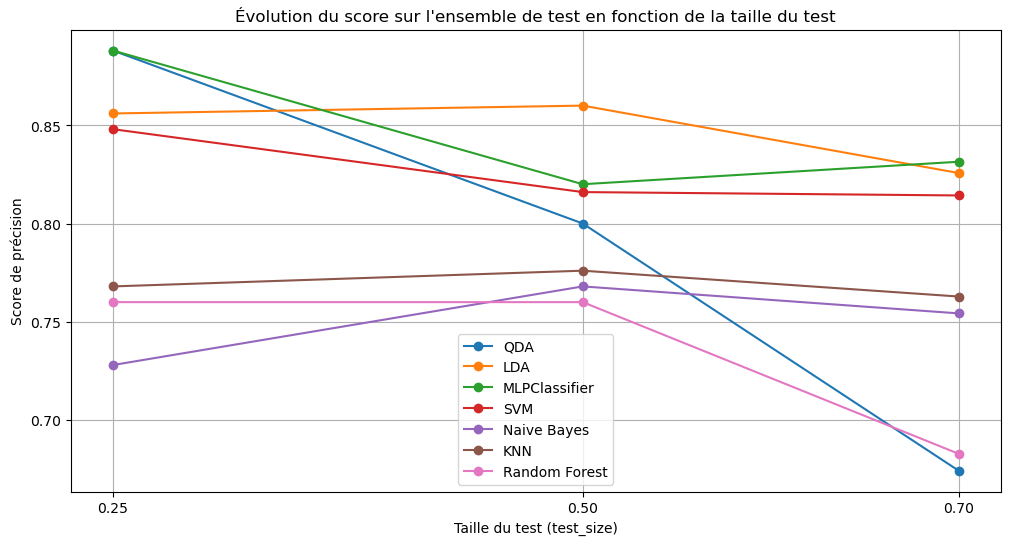

In [67]:
modeles = {
    'QDA': (QuadraticDiscriminantAnalysis(), {}),
    'LDA': (LinearDiscriminantAnalysis(), {}),
    'MLPClassifier': (MLPClassifier(random_state=42, max_iter=1000), {
        'hidden_layer_sizes': [(200,),(100,)],
        'activation': ['tanh', 'relu'],
        'alpha': [0.0001, 0.001],
    }),
    'SVM': (SVC(random_state=42),{
        'C': [0.1, 1, 10],
        'kernel': ['linear', 'rbf'],
        'gamma': ['scale', 'auto']

    }),
    'Naive Bayes': (GaussianNB(), {}),
    'KNN': (KNeighborsClassifier(), {
        'n_neighbors': [3, 5, 7],
        'weights': ['uniform', 'distance']
    }),
    'Random Forest': (RandomForestClassifier(random_state=42), {
        'n_estimators': [100, 200],
        'max_depth': [None, 5, 10],
        'min_samples_split': [2, 5]
    }),
    
}
# Liste des tailles de test
tests_sizes = [0.25, 0.5, 0.7]

# Dictionnaire pour stocker les scores
scores_t = {modele_nom: [] for modele_nom in modeles.keys()}

# Boucle sur chaque taille de test
for test_size in tests_sizes:
    print(f"\nTest size: {test_size}")
    
    # Division des données
    X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(X, y, test_size=test_size,shuffle=True, random_state=0)
    
    # Pour chaque modèle
    for nom, (modele, params) in modeles.items():
        # Création du pipeline
        steps = []
        steps.append(('scaler', StandardScaler()))
        steps.append(('classifier', modele))
        pipeline = Pipeline(steps)
        
        # Paramètres pour GridSearchCV
        pipeline_params = {f'classifier__{key}': value for key, value in params.items()}
        
        # GridSearchCV avec validation croisée
        grid_search = GridSearchCV(
            pipeline,
            pipeline_params,
            cv=5,
            scoring='accuracy',
            n_jobs=-1,
            verbose=0
        )
    
        # Entraînement
        grid_search.fit(X_train_t, y_train_t)
        
        # Prédictions
        y_pred_t = grid_search.predict(X_test_t)
        
        # Calcul du score sur le test
        test_score_t = accuracy_score(y_test_t, y_pred_t)
        scores_t[nom].append(test_score_t)
        
        # Affichage du score
        print(f" - {nom}: Score sur le test: {test_score_t:.4f}")

        
# Tracé des courbes d'évolution des scores
plt.figure(figsize=(12, 6))
for m_model_nom , modele_scores in scores_t.items():
    plt.plot(tests_sizes, modele_scores, marker='o', label=m_model_nom )

plt.title("Évolution du score sur l'ensemble de test en fonction de la taille du test")
plt.xlabel('Taille du test (test_size)')
plt.ylabel('Score de précision')
plt.xticks(tests_sizes)
plt.legend()
plt.grid(True)
plt.show()

Le modèle **QDA** est le meilleur avec un score de 88.8% sur un ensemble de test de 25%

Mais pour un plus grand ensemble de test on remarque que le QDA sous performe , tandis que ***le LDA le SVM et le MLPClassifier*** maientiennent des scores élevés malgre la taille de l'ensemble de test.

On va étudier la capacité de ces modèles à généraliser.


Évaluation de LDA
Score moyen: 0.8700 (+/- 0.0237)

Évaluation de QDA
Score moyen: 0.8780 (+/- 0.0570)

Évaluation de SVM
Score moyen: 0.8620 (+/- 0.0414)

Évaluation de MLPClassifier
Score moyen: 0.8780 (+/- 0.0208)

=== Résultats finaux ===
Meilleur modèle (stabilité): MLPClassifier
Score moyen: 87.80%
Écart-type: 0.0104
Score de stabilité: 86.90%

Récapitulatif des performances:
          Modèle  Score Moyen  Écart-type  Score Stabilité
3  MLPClassifier        0.878    0.010392         0.868969
0            LDA        0.870    0.011832         0.859826
1            QDA        0.878    0.028496         0.853674
2            SVM        0.862    0.020688         0.844528


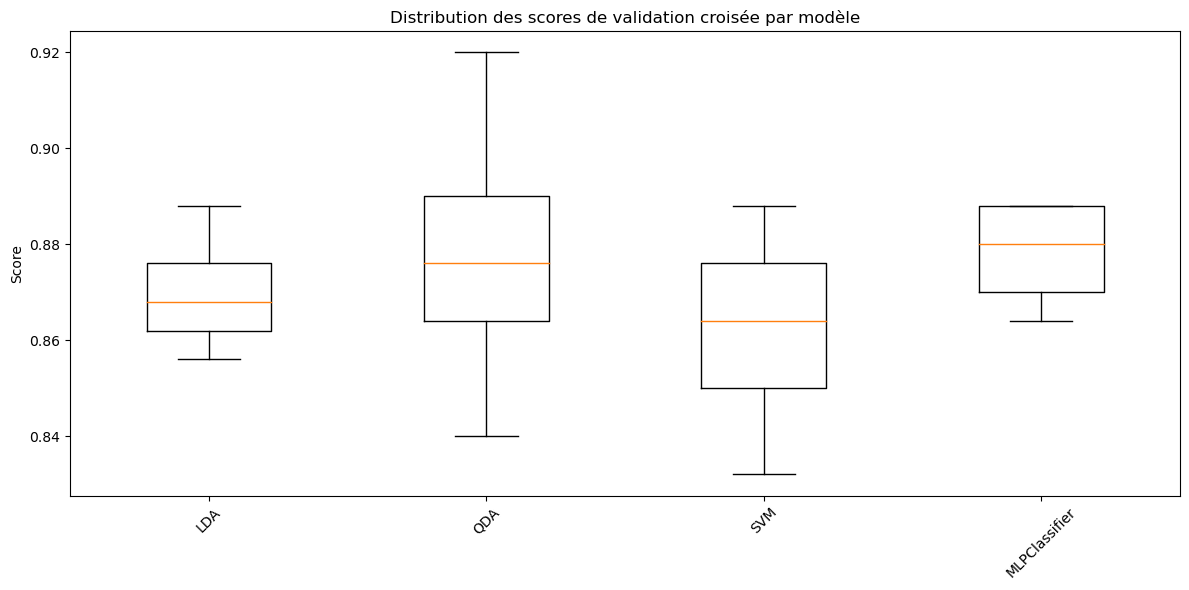

In [68]:

# Préparation des données
X = df[[f"MFCC_{i}" for i in range(1, 11)]].values
y = df['SpeakerID'].values

# Configuration de la validation croisée stratifiée
cv_outer = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)
cv_inner = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Définition des modèles et des paramètres
modelss = {
    'LDA': (LinearDiscriminantAnalysis(), {}),
    'QDA': (QuadraticDiscriminantAnalysis(), {}),
    'SVM': (SVC(probability=True), {
        'classifier__C': [1],
        'classifier__kernel': ['linear', 'rbf'],
        'classifier__gamma': ['scale', 'auto']
    }),
     'MLPClassifier': (MLPClassifier(random_state=42, max_iter=2000), {
        'classifier__hidden_layer_sizes': [(100,),(200,)],
        'classifier__activation': ['tanh', 'relu'],
        'classifier__alpha': [0.0001, 0.001],
    })
    
}

# Dictionnaire pour stocker les résultats
resultat = {}

# Pour chaque modèle
for name, (model, params) in modelss.items():
    print(f"\nÉvaluation de {name}")

    '''Création du pipeline  pour standardiser les données (avec StandardScaler) 
    et pour intégrer le modèle de classification'''
    steps = []
    steps.append(('scaler', StandardScaler()))
    steps.append(('classifier', model))
    pipeline = Pipeline(steps)
    
    ''' Validation croisée imbriquée Validation interne (cv_inner) : 
    Utilisée pour optimiser les hyperparamètres via GridSearchCV.
    Validation externe (cv_outer) : Utilisée pour estimer la performance généralisée du modèle optimisé.'''
    if params:
        # Si le modèle a des hyperparamètres à optimiser
        grid_search = GridSearchCV(
            pipeline, 
            params, 
            cv=cv_inner,
            scoring='accuracy',
            n_jobs=-1
        )
        # Scores sur validation croisée externe
        nested_scores = cross_val_score(
            grid_search, X, y, 
            cv=cv_outer,
            scoring='accuracy',
            n_jobs=-1
        )
    else:
        # Si pas d'hyperparamètres à optimiser
        nested_scores = cross_val_score(
            pipeline, X, y,
            cv=cv_outer,
            scoring='accuracy',
            n_jobs=-1
        )
    
    # Stockage des résultats
    resultat[name] = {
        'mean_score': nested_scores.mean(),
        'std_score': nested_scores.std(),
        'scores': nested_scores,
        'model': pipeline
    }
    # Affichage du score moyen et de l'écart-type
    print(f"Score moyen: {nested_scores.mean():.4f} (+/- {nested_scores.std()*2:.4f})")

'''Calcul du score de stabilité :Ce score permet de prendre 
en compte à la fois la performance moyenne et la variabilité du modèle(sa capacite a generaliser).'''
for name in resultat:
    resultat[name]['stability_score'] = resultat[name]['mean_score'] / (1 + resultat[name]['std_score'])

# Trouver le meilleur modèle basé sur le score de stabilité
m_model_nom2 = max(resultat.items(), key=lambda x: x[1]['stability_score'])[0]

print("\n=== Résultats finaux ===")
print(f"Meilleur modèle (stabilité): {m_model_nom2}")
print(f"Score moyen: {resultat[m_model_nom2]['mean_score']:.2%}")
print(f"Écart-type: {resultat[m_model_nom2]['std_score']:.4f}")
print(f"Score de stabilité: {resultat[m_model_nom2]['stability_score']:.2%}")

# Tableau récapitulatif des performances
resultat_df = pd.DataFrame({
    'Modèle': list(resultat.keys()),
    'Score Moyen': [resultat[name]['mean_score'] for name in resultat],
    'Écart-type': [resultat[name]['std_score'] for name in resultat],
    'Score Stabilité': [resultat[name]['stability_score'] for name in resultat]
})

print("\nRécapitulatif des performances:")
print(resultat_df.sort_values('Score Stabilité', ascending=False))

# Visualisation de la distribution des scores pour chaque modèle
plt.figure(figsize=(12, 6))
scores_data = [resultat[name]['scores'] for name in resultat]
plt.boxplot(scores_data, labels=list(resultat.keys()))
plt.title('Distribution des scores de validation croisée par modèle')
plt.xticks(rotation=45)
plt.ylabel('Score')
plt.tight_layout()
plt.show() 

### Interprétation du Boxplot

Le boxplot représente la distribution des scores de validation croisée obtenus pour chaque modèle évalué. Chaque boîte à moustaches correspond à un modèle et visualise la dispersion des scores de précision obtenus lors des différentes itérations de la validation croisée.
### Interprétation des Résultats:

***MLPClassifier*** est le modèle ayant obtenu le meilleur score de stabilité (86,9%) avec un score moyen élevé (87,80%) et le plus faible écart-type (0,0208). Cela indique que le MLPClassifier non seulement performe bien en moyenne, mais que ses performances sont cohérentes à travers les différentes itérations de validation croisée.

***QDA*** et ***LDA*** suivent de près avec des scores de stabilité respectifs de 85,36% et 85,98%. Le QDA a un score moyen élevé (87,80%) mais un écart-type légèrement supérieur, ce qui réduit légèrement son score de stabilité par rapport au MLPClassifier.

***SVM*** est le pire modèle avec un écart type élevé et un score moyen faible.

### Conclusion :

Le MLPClassifier est le modèle le plus performant et le plus stable. Sa haute précision couplée à une faible variabilité montre ca capacite a contourner l'overfitting sur des donnees de validation privees . Le modèle QDA est aussi  performant en terme de score mais a une faible capacité de genéralisation (forte variance) .
 
***On choisi donc le MLPClassifier avec les parametres suivants "classifier__hidden_layer_sizes': [(200,)],
        'classifier__activation': ['tanh'], 'classifier__alpha': [0.0001]" comme modèle final pour la reconnaissance vocale.***


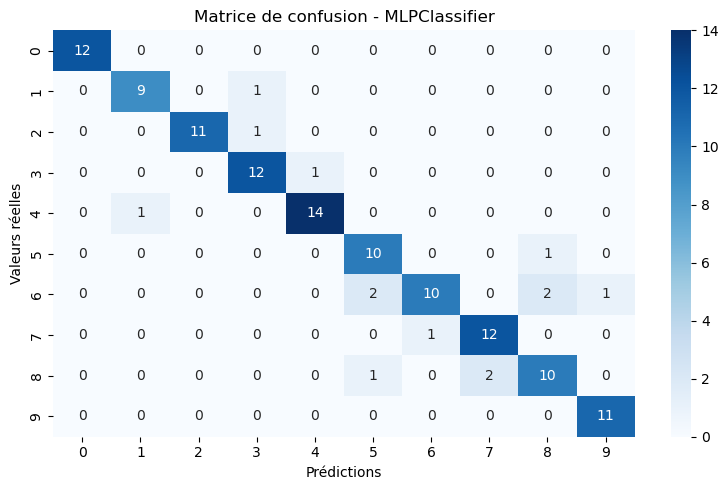

Score sur l'ensemble de test: 88.80%


In [69]:
# Création du MLPClassifier avec les paramètres spécifiés
mlp = MLPClassifier(
    hidden_layer_sizes=(200,),
    activation='tanh',
    alpha=0.0001,
    max_iter=2000,
    random_state=42
)

# Création et entrainement du pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', mlp)
])

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

# Création de la matrice de confusion
cm = confusion_matrix(y_test, y_pred)

# Visualisation
plt.figure(figsize=(8, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matrice de confusion - MLPClassifier')
plt.xlabel('Prédictions')
plt.ylabel('Valeurs réelles')
plt.tight_layout()
plt.show()

# Affichage du score
print(f"Score sur l'ensemble de test: {pipeline.score(X_test, y_test):.2%}")

#### Bonus: Enrichissez le dataset avec des enregistrements de votre propre voix. Le modèle est-il capable de vous reconnaitre ?

In [70]:
import pandas as pd
import librosa
import os

def extract_mfcc_features(audio_path, n_coefs):
    y, sr = librosa.load(audio_path)
    return librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_coefs).mean(axis=1)

folder_path = "dataBonus/raw/"
n_recordings = 50
n_coefs = 10
data = []

# Traitement des fichiers originaux (format: f0001_us_f0001_00001.wav)
for gender in ["m", "f"]:
    for speaker in range(1, 6):
        for recording_id in range(1, n_recordings + 1):
            file_name = f"{gender}{speaker:04d}_us_{gender}{speaker:04d}_{recording_id:05d}.wav"
            file_path = os.path.join(folder_path, file_name)
            
            if os.path.exists(file_path):
                mfcc = extract_mfcc_features(file_path, n_coefs)
                speaker_id = speaker - 1
                if gender == "f":
                    speaker_id += 5
                    
                row_data = {
                    'FileName': file_name,
                    'Gender': gender,
                    'SpeakerID': speaker_id,
                    'RecordingID': recording_id,
                }
                for i in range(n_coefs):
                    row_data[f'MFCC_{i+1}'] = mfcc[i]
                data.append(row_data)

# Traitement des fichiers personnels (format: A1.wav)
for recording_id in range(1, n_recordings + 1):
    file_name = f"A{recording_id}.wav"
    file_path = os.path.join(folder_path, file_name)
    
    if os.path.exists(file_path):
        mfcc = extract_mfcc_features(file_path, n_coefs)
        row_data = {
            'FileName': file_name,
            'Gender': 'm',
            'SpeakerID': 10,  # Nouvel ID pour vos enregistrements
            'RecordingID': recording_id,
        }
        for i in range(n_coefs):
            row_data[f'MFCC_{i+1}'] = mfcc[i]
        data.append(row_data)

# Création du DataFrame
df_bonus = pd.DataFrame(data)

In [71]:
df_bonus.tail(100)

,FileName,Gender,SpeakerID,RecordingID,MFCC_1,MFCC_2,MFCC_3,MFCC_4,MFCC_5,MFCC_6,MFCC_7,MFCC_8,MFCC_9,MFCC_10
450,f0005_us_f0005_00001.wav,f,9,1,-429.397217,68.207664,-20.677948,32.679424,-12.282600,-2.436867,-20.107405,-5.013668,-10.999745,2.176368
451,f0005_us_f0005_00002.wav,f,9,2,-376.464478,86.984749,-27.196104,45.474892,-8.962668,-6.112698,-26.458397,-1.731810,-12.230350,3.125959
452,f0005_us_f0005_00003.wav,f,9,3,-511.976501,76.224792,-5.848817,36.650887,-1.161692,3.995057,-14.667454,-0.546313,-9.126673,0.371821
453,f0005_us_f0005_00004.wav,f,9,4,-434.769928,72.909485,-28.455978,35.084469,-9.345699,-0.738353,-23.833300,3.029342,-12.444795,6.128580
454,f0005_us_f0005_00005.wav,f,9,5,-415.769623,65.173126,-15.698808,38.446198,-9.700392,-5.057718,-21.218195,-1.505609,-9.198173,2.460125
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
545,A46.wav,m,10,46,-337.867523,109.523888,20.635824,35.800121,24.185713,2.933545,12.195034,-6.821723,-20.217150,5.282370
546,A47.wav,m,10,47,-331.032166,125.273689,16.551649,12.185011,11.245252,9.050293,7.174203,-4.043534,-19.033482,6.848664
547,A48.wav,m,10,48,-325.620148,117.682152,16.731951,20.930666,18.864988,1.021566,12.584999,-1.982876,-19.081453,6.813874
548,A49.wav,m,10,49,-325.895874,118.913986,21.719296,23.835550,18.377390,1.888706,14.412525,-7.439672,-25.294930,2.428751


In [72]:
# Préparation des données avec le dataset enrichi 
X_bonus = df_bonus[[f"MFCC_{i}" for i in range(1, 11)]].values
y_bonus = df_bonus.SpeakerID.values

# Division en ensembles d'entraînement et de test
X_train_bonus, X_test_bonus, y_train_bonus, y_test_bonus = train_test_split(
    X_bonus, y_bonus, test_size=0.25, random_state=0, shuffle=True
)

# Création et entraînement du MLPClassifier
mlp_bonus = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', MLPClassifier(
        hidden_layer_sizes=(200,),
        activation='tanh',
        alpha=0.0001,
        max_iter=2000,
        random_state=42
    ))
])

mlp_bonus.fit(X_train_bonus, y_train_bonus)

Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier',
                 MLPClassifier(activation='tanh', hidden_layer_sizes=(200,),
                               max_iter=2000, random_state=42))])

In [73]:
X_test_bonus_df=pd.DataFrame(X_test_bonus)
X_test_bonus_df.head()

,0,1,2,3,4,5,6,7,8,9
0,-538.551575,77.392502,11.531985,34.637886,-6.272859,12.658236,-10.058226,10.016952,-13.395230,-0.359374
1,-493.274261,83.849068,-1.334502,35.039688,-10.790273,9.459198,-34.778999,13.540378,-8.225257,-2.218283
2,-512.952576,83.931587,5.176713,36.129498,-6.204999,18.913424,-16.651136,9.683000,-12.403950,2.699061
3,-478.512817,100.200790,-0.740948,17.903027,2.305678,14.221535,-7.262125,-0.743044,-7.701019,0.715951
4,-518.213379,91.723366,-10.911754,40.921768,-4.176298,20.619190,-14.657209,0.895899,-12.529888,3.886443


In [74]:
# Isoler vos enregistrements (SpeakerID=10)
# Faire des prédictions
predictions = mlp_bonus.predict(X_test_bonus)
accuracy_test_ = accuracy_score(predictions, y_test_bonus)
print(f"Précision sur le test: {accuracy_test_:.2%}")


Précision sur le test: 90.58%


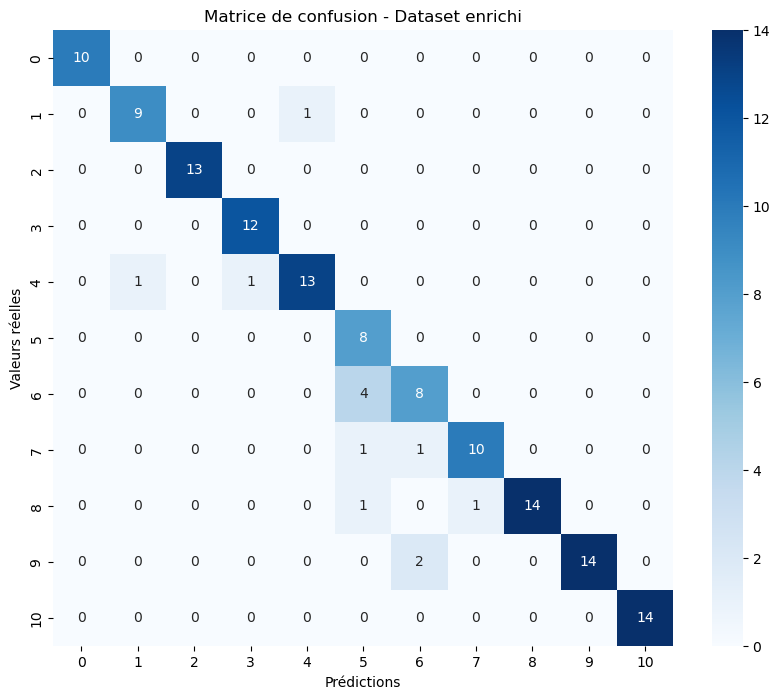

In [75]:
# Prédictions sur l'ensemble de test
y_pred_bonus = mlp_bonus.predict(X_test_bonus)

# Création de la matrice de confusion
cm_bonus = confusion_matrix(y_test_bonus, y_pred_bonus)

# Visualisation
plt.figure(figsize=(10, 8))
sns.heatmap(cm_bonus, annot=True, fmt='d', cmap='Blues')
plt.title('Matrice de confusion - Dataset enrichi')
plt.xlabel('Prédictions')
plt.ylabel('Valeurs réelles')
plt.show()

## Robustesse face aux Nouvelles Classes:
   - Le classificateur a démontré une robustesse face à l’ajout d'une nouvelle classe (Speaker 10). Malgré l’introduction d’un speaker supplémentaire, ce qui peut accroître les risques de confusion entre speakers, le modèle a conservé une bonne capacité de classification pour la majorité des échantillons.
   - Cette robustesse indique que le classificateur est capable de bien généraliser même lorsque de nouveaux speakers sont ajoutés à l’ensemble de données, une caractéristique précieuse pour des applications réelles où de nouveaux speakers peuvent être fréquemment introduits.


# ANNEXE:T_SNE

<Axes: xlabel='0', ylabel='1'>

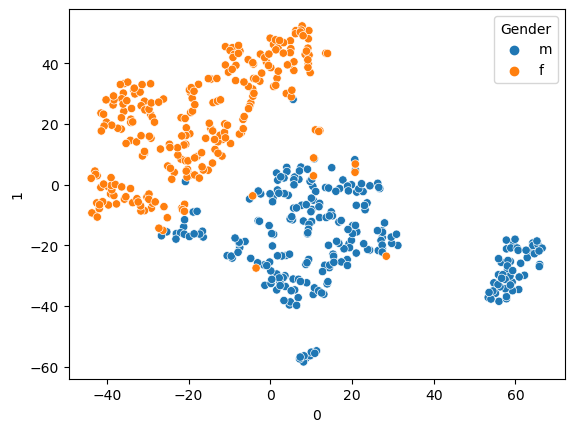

In [76]:
t_sne=TSNE(n_components=2,perplexity=10,learning_rate=100, random_state=0)
X_embedded=t_sne.fit_transform(X_scaled)
X_embedded_df=pd.DataFrame(X_embedded)
X_embedded_df['Gender']=df['Gender']
sns.scatterplot(data=X_embedded_df,x=X_embedded_df.iloc[:, 0],y=X_embedded_df.iloc[: ,1],hue='Gender')